In [1]:
import glob
import numpy as np
from tqdm import tqdm
from natsort import natsorted
import pickle
import pandas as pd
import cv2
from lib.trainer import ResShiftTrainer, MocolskTrainer
from lib.functions import *
from lib.utils import calculate_spectral_indices
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error as rmse
import matplotlib.colors as mcolors

plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'Times New Roman'

folder_landsat_glb = r'D:\zhy\data\SR\landsat_glb_resampled'
files_landsat_glb_landsat = natsorted(glob.glob(folder_landsat_glb + r'\*landsat*.tif'))
files_landsat_glb_dem = natsorted(glob.glob(folder_landsat_glb + r'\*dem*.tif'))

folder_aster_glb = r'D:\zhy\data\SR\aster_glb_resampled'
files_aster_glb_dem = natsorted(glob.glob(folder_aster_glb + r'\*dem_resample*.tif'))

# over the Landsat_GLB dataset

In [9]:
scale_factor = 20
hr_size, patch_size = 480, 160
lr_size = hr_size // scale_factor
lst_all = {}

# kernel-driven model and DCF model
lst_hr_true_all, lst_hr_kd1_all, lst_hr_kd2_all, lst_hr_itp_all = [], [], [], []

for file_landsat, file_dem in tqdm(zip(files_landsat_glb_landsat, files_landsat_glb_dem), total=len(files_landsat_glb_landsat)):
    data_landsat,_,_ = read_tiff(file_landsat, missing_value=-999)
    dem,_,_ = read_tiff(file_dem, missing_value=-999)

    lst_hr = data_landsat[-1] * 0.00341802 + 149
    lst_lr = np.mean(lst_hr.reshape(lr_size, scale_factor, lr_size, scale_factor)**4, axis=(1, 3)) ** 0.25

    ref = data_landsat[:-1] * 2.75e-05 - 0.2
    ref[ref < 0] = 0
    ref[ref > 1] = 1
    ndvi = calculate_spectral_indices(ref[3], ref[2])  # NIR and R
    ndwi = calculate_spectral_indices(ref[1], ref[3])  # G and NIR
    ndmi = calculate_spectral_indices(ref[3], ref[4]) # NIR and SWIR1
    gui_hr = np.concatenate((ref, ndvi[None,...], ndwi[None,...], ndmi[None,...] , dem[None,...]), axis=0)

    model1 = LinearRegression()
    model2 = RandomForestRegressor(random_state=42)
    lst_hr_kd1 = kernel_driven_model(model1, 'bilinear', lst_lr, gui_hr, scale_factor)
    lst_hr_kd2 = kernel_driven_model(model2, 'bilinear', lst_lr, gui_hr, scale_factor)
    lst_hr_itp = cv2.resize(lst_lr, dsize=(hr_size, hr_size), interpolation=cv2.INTER_LINEAR)  # bilinear interpolation

    lst_hr_true_all.append(lst_hr)
    lst_hr_kd1_all.append(lst_hr_kd1)
    lst_hr_kd2_all.append(lst_hr_kd2)
    lst_hr_itp_all.append(lst_hr_itp)

lst_all['true'] = np.stack(lst_hr_true_all)
lst_all['itp'] = np.stack(lst_hr_itp_all)
lst_all['kd1'] = np.stack(lst_hr_kd1_all)
lst_all['kd2'] = np.stack(lst_hr_kd2_all)

a = 0.57 if scale_factor == 10 else 0.50
lst_all['dcf1'] = a * lst_all['kd1'] + (1 - a) * lst_all['itp']
lst_all['dcf2'] = a * lst_all['kd2'] + (1 - a) * lst_all['itp']

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:36<00:00,  1.84s/it]


In [ ]:
# for deep learning models
var_name1 = f"resshift_v1_{scale_factor}x"
trainer_pgdm = ResShiftTrainer(config_base_path="configs/base.yaml", config_var_path="configs/var.yaml", var_name=var_name1)
trainer_pgdm.set_seed_during_diffusion(42)
trainer_pgdm.reload_model(model_path=f'models/{var_name1}_best.pth')
trainer_pgdm.load_testset_Landsat_GLB(fixed_drop_channels=[10])

var_name2 = f"mocolsk_v1_{scale_factor}x"
trainer_moco = MocolskTrainer(config_base_path="configs/base.yaml", config_var_path="configs/var.yaml", var_name=var_name2)
trainer_moco.reload_model(model_path=f'models/{var_name2}_best.pth')

testloader = trainer_pgdm.testloader_landsat_glb
_, lst_hr_mocolsk_patches = trainer_moco.evaluate_after_train(testloader)
_, lst_hr_pgdm_patches = trainer_pgdm.evaluate_after_train(testloader)

# combine patches into full-size images
step = 80
num_patches = ((hr_size - patch_size) // step + 1)**2
num_area = lst_hr_pgdm_patches.shape[0] // num_patches
lst_hr_pgdm_all, lst_hr_mocolsk_all = [], []
for i in range(num_area):
    lst_hr_pgdm_all.append(combine_patches(lst_hr_pgdm_patches[i*num_patches:(i+1)*num_patches], original_size=(hr_size, hr_size), patch_size=patch_size, step=step))
    lst_hr_mocolsk_all.append(combine_patches(lst_hr_mocolsk_patches[i*num_patches:(i+1)*num_patches], original_size=(hr_size, hr_size), patch_size=patch_size, step=step))
lst_all['pgdm'] = np.array(lst_hr_pgdm_all)
lst_all['mocolsk'] = np.array(lst_hr_mocolsk_all)

100%|██████████| 16/16 [00:07<00:00,  2.24it/s]


In [11]:
# accuracy metrics
keys = ['itp', 'kd1', 'kd2', 'dcf1', 'dcf2', 'mocolsk', 'pgdm']
df = pd.DataFrame(columns=['Method', 'RMSE', 'Bias', 'SSIM', 'Loss_phy'])
for key in keys:
    rmse_val, bias_val, ssim_val, loss_phy = calculate_accuracy_metrics(lst_all['true'], lst_all[key], lr_size, scale_factor)
    df.loc[len(df), :] = [key, round(rmse_val, 3), round(bias_val, 3), round(ssim_val, 3), round(loss_phy, 3)]
df.to_csv(f'results/accuracy_metrics_landsat_glb_{scale_factor}x.csv', index=False)
print(df)

with open(f'results/landsat_glb_{scale_factor}x.pkl', 'wb') as f:
    pickle.dump(lst_all, f)

    Method   RMSE   Bias   SSIM Loss_phy
0      itp  2.579  0.034  0.768    0.669
1      kd1  2.151  0.034  0.831      0.3
2      kd2   2.02 -0.091  0.854    0.837
3     dcf1  1.702  0.034  0.888    0.393
4     dcf2    1.8 -0.028  0.886    0.624
5  mocolsk  1.353 -0.003  0.915    0.073
6     pgdm  1.126  0.017  0.937    0.079


# over the ASTER_GLB dataset

In [2]:
scale_factor = 10
hr_size, patch_size = 480, 160
lr_size = hr_size // scale_factor
lst_all = {}

# kernel-driven model and DCF model
lst_hr_true_all, lst_hr_kd1_all, lst_hr_kd2_all, lst_hr_itp_all = [], [], [], []
lst_lr_true_all = []

for file_dem in tqdm(files_aster_glb_dem):
    file_lst = file_dem.replace('dem_resample', 'lst_resample')
    file_hls = file_lst.replace('lst_resample', 'hls_resample')
    
    dem = read_tiff(file_dem, missing_value=-999.)[0]
    ref = read_tiff(file_hls, missing_value=-999.)[0]
    ref[ref<0] = 0
    ref[ref>1] = 1
    ndvi = calculate_spectral_indices(ref[3], ref[2])  # NIR and R
    ndwi = calculate_spectral_indices(ref[1], ref[3])  # G and NIR
    ndmi = calculate_spectral_indices(ref[3], ref[4]) # NIR and SWIR1
    gui_hr = np.concatenate((ref, ndvi[None,...], ndwi[None,...], ndmi[None,...] , dem[None,...]), axis=0)

    lst_hr = read_tiff(file_lst, scale=0.1, missing_value=2000)[0]
    lst_lr = np.mean(lst_hr.reshape(lr_size, scale_factor, lr_size, scale_factor)**4, axis=(1, 3)) ** 0.25

    model1 = LinearRegression()
    model2 = RandomForestRegressor(random_state=42)
    lst_hr_kd1 = kernel_driven_model(model1, 'bilinear', lst_lr, gui_hr, scale_factor)
    lst_hr_kd2 = kernel_driven_model(model2, 'bilinear', lst_lr, gui_hr, scale_factor)
    lst_hr_itp = cv2.resize(lst_lr, dsize=(hr_size, hr_size), interpolation=cv2.INTER_LINEAR)  # bilinear interpolation

    lst_hr_true_all.append(lst_hr)
    lst_hr_kd1_all.append(lst_hr_kd1)
    lst_hr_kd2_all.append(lst_hr_kd2)
    lst_hr_itp_all.append(lst_hr_itp)
    lst_lr_true_all.append(lst_lr)

lst_all['true'] = np.stack(lst_hr_true_all)
lst_all['itp'] = np.stack(lst_hr_itp_all)
lst_all['kd1'] = np.stack(lst_hr_kd1_all)
lst_all['kd2'] = np.stack(lst_hr_kd2_all)

a = 0.57 if scale_factor == 10 else 0.50
lst_all['dcf1'] = a * lst_all['kd1'] + (1 - a) * lst_all['itp']
lst_all['dcf2'] = a * lst_all['kd2'] + (1 - a) * lst_all['itp']

100%|██████████| 20/20 [01:17<00:00,  3.86s/it]


In [5]:
# for deep learning models
var_name_1 = f"resshift_{scale_factor}x_nearest" # f"resshift_v1_{scale_factor}x"
trainer_pgdm = ResShiftTrainer(config_base_path="configs/base.yaml", config_var_path="configs/var.yaml", var_name=var_name_1)
trainer_pgdm.set_seed_during_diffusion(42)
trainer_pgdm.reload_model(model_path=f'models/{var_name_1}_best.pth')
trainer_pgdm.load_testset_ASTER_GLB(fixed_drop_channels=[10])

var_name_2 = f"mocolsk_v1_{scale_factor}x"
trainer_moco = MocolskTrainer(config_base_path="configs/base.yaml", config_var_path="configs/var.yaml", var_name=var_name_2)
trainer_moco.reload_model(model_path=f'models/{var_name_2}.pth')

testloader = trainer_pgdm.testloader_aster_glb
_, lst_hr_mocolsk_patches = trainer_moco.evaluate_after_train(testloader)
_, lst_hr_pgdm_patches = trainer_pgdm.evaluate_after_train(testloader)

# combine patches into full-size images
step = 80
num_patches = ((hr_size - patch_size) // step + 1)**2
num_area = lst_hr_pgdm_patches.shape[0] // num_patches
lst_hr_pgdm_all, lst_hr_mocolsk_all = [], []
for i in range(num_area):
    lst_hr_pgdm_all.append(combine_patches(lst_hr_pgdm_patches[i*num_patches:(i+1)*num_patches], original_size=(hr_size, hr_size), patch_size=patch_size, step=step))
    lst_hr_mocolsk_all.append(combine_patches(lst_hr_mocolsk_patches[i*num_patches:(i+1)*num_patches], original_size=(hr_size, hr_size), patch_size=patch_size, step=step))
lst_all['pgdm'] = np.array(lst_hr_pgdm_all)
lst_all['mocolsk'] = np.array(lst_hr_mocolsk_all)

100%|██████████| 16/16 [00:05<00:00,  2.75it/s]


In [68]:
# save results
keys = ['itp', 'kd1', 'kd2', 'dcf1', 'dcf2', 'mocolsk', 'pgdm']
df = pd.DataFrame(columns=['Method', 'RMSE', 'Bias', 'SSIM', 'Loss_phy'])
for key in keys:
    rmse_val, bias_val, ssim_val, loss_phy = calculate_accuracy_metrics(lst_all['true'], lst_all[key], lr_size, scale_factor)
    df.loc[len(df), :] = [key, round(rmse_val, 3), round(bias_val, 3), round(ssim_val, 3), round(loss_phy, 3)]
df.to_csv(f'results/accuracy_metrics_aster_glb_{scale_factor}x.csv', index=False)
print(df)

with open(f'results/aster_glb_{scale_factor}x.pkl', 'wb') as f:
    pickle.dump(lst_all, f)

    Method   RMSE   Bias   SSIM Loss_phy
0      itp   2.78  0.039  0.728    0.627
1      kd1  2.731  0.039  0.742    0.293
2      kd2  2.589 -0.082  0.763    0.808
3     dcf1  2.275  0.039   0.79    0.378
4     dcf2   2.33 -0.021   0.79      0.6
5  mocolsk  2.036  0.006  0.821     0.07
6     pgdm   1.93  0.021  0.833    0.067


In [ ]:
# test different model structure for ResShift
var_name_1 = f"resshift_{scale_factor}x_ch64" # f"resshift_v1_{scale_factor}x"
trainer_pgdm = ResShiftTrainer(config_base_path="configs/base.yaml", config_var_path="configs/var.yaml", var_name=var_name_1)
trainer_pgdm.set_seed_during_diffusion(42)
trainer_pgdm.reload_model(model_path=f'models/{var_name_1}_best.pth')
trainer_pgdm.load_testset_ASTER_GLB(fixed_drop_channels=[10])

testloader = trainer_pgdm.testloader_aster_glb
_, lst_hr_pgdm_patches = trainer_pgdm.evaluate_after_train(testloader)

# combine patches into full-size images
step = 80
num_patches = ((hr_size - patch_size) // step + 1)**2
num_area = lst_hr_pgdm_patches.shape[0] // num_patches
lst_hr_pgdm_all = []
for i in range(num_area):
    lst_hr_pgdm_all.append(combine_patches(lst_hr_pgdm_patches[i*num_patches:(i+1)*num_patches], original_size=(hr_size, hr_size), patch_size=patch_size, step=step))
lst_all['pgdm'] = np.array(lst_hr_pgdm_all)

# save results
keys = ['itp', 'kd1', 'kd2', 'dcf1', 'dcf2', 'mocolsk', 'pgdm']
df = pd.DataFrame(columns=['Method', 'RMSE', 'Bias', 'SSIM', 'Loss_phy'])
for key in keys:
    rmse_val, bias_val, ssim_val, loss_phy = calculate_accuracy_metrics(lst_all['true'], lst_all[key], lr_size, scale_factor)
    df.loc[len(df), :] = [key, round(rmse_val, 3), round(bias_val, 3), round(ssim_val, 3), round(loss_phy, 3)]
print(df)

100%|██████████| 32/32 [00:25<00:00,  1.25it/s]


    Method   RMSE   Bias   SSIM Loss_phy
0      itp  2.378  0.029  0.748    0.622
1      kd1  2.507  0.029   0.76    0.354
2      kd2  2.484 -0.071  0.766    0.843
3     dcf1  2.079  0.029  0.801    0.387
4     dcf2  2.112 -0.028  0.802    0.631
5  mocolsk   1.87  0.002  0.837    0.064
6     pgdm  1.749  0.011  0.852    0.024


# load the results for analysis

In [188]:
factor = 20
lr_size = 480 // factor
name = f'aster_glb_{factor}x'
lst_dic = pickle.load(open(f'results/{name}.pkl', 'rb'))
data_range = lst_dic['true'].max() - lst_dic['true'].min()

In [189]:
# landsat: 18 (santiago) for 10x and 10 (lake_tahoe) for 20x
# aster: 14 (namibia) for 10x and 6 (yueyang) for 20x
idx = 14
region = 'namibia'
lst_all = [lst_dic['itp'][idx], lst_dic['kd1'][idx], lst_dic['kd2'][idx], lst_dic['dcf1'][idx], 
           lst_dic['dcf2'][idx], lst_dic['mocolsk'][idx], lst_dic['pgdm'][idx], lst_dic['true'][idx]]
titles_all = ['Bilinear interpolation', 'Kernel-driven (Linear)', 'Kernel-driven (RF)', 'DCF (Linear)', 
              'DCF (RF)', 'MoCoLSK-Net', 'PGDM', 'Ground Truth']

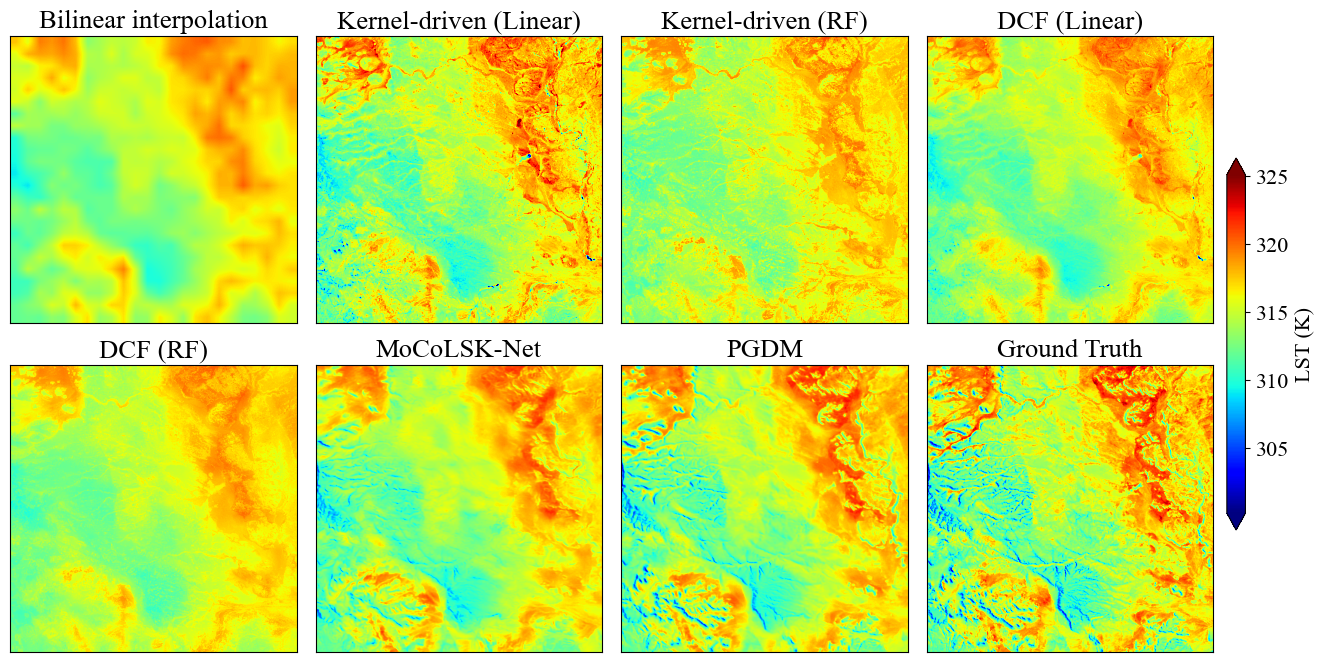

In [190]:
# downscale results
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
vmin, vmax = lst_all[-1].min(), lst_all[-1].max()
axs = axs.flatten()

for i in range(8):
    im = axs[i].imshow(lst_all[i], cmap='jet', vmin=vmin, vmax=vmax)
    axs[i].set_title(titles_all[i])
    axs[i].set_xticks([])
    axs[i].set_yticks([])

# add colorbar
cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.015, pad=0.02, extend='both')
cbar.set_label('LST (K)')

fig.subplots_adjust(wspace=0.05, hspace=0.15, right=0.88)
plt.savefig(f'figs/dlst_map_{region}_{name}.tif', dpi=300, bbox_inches='tight')

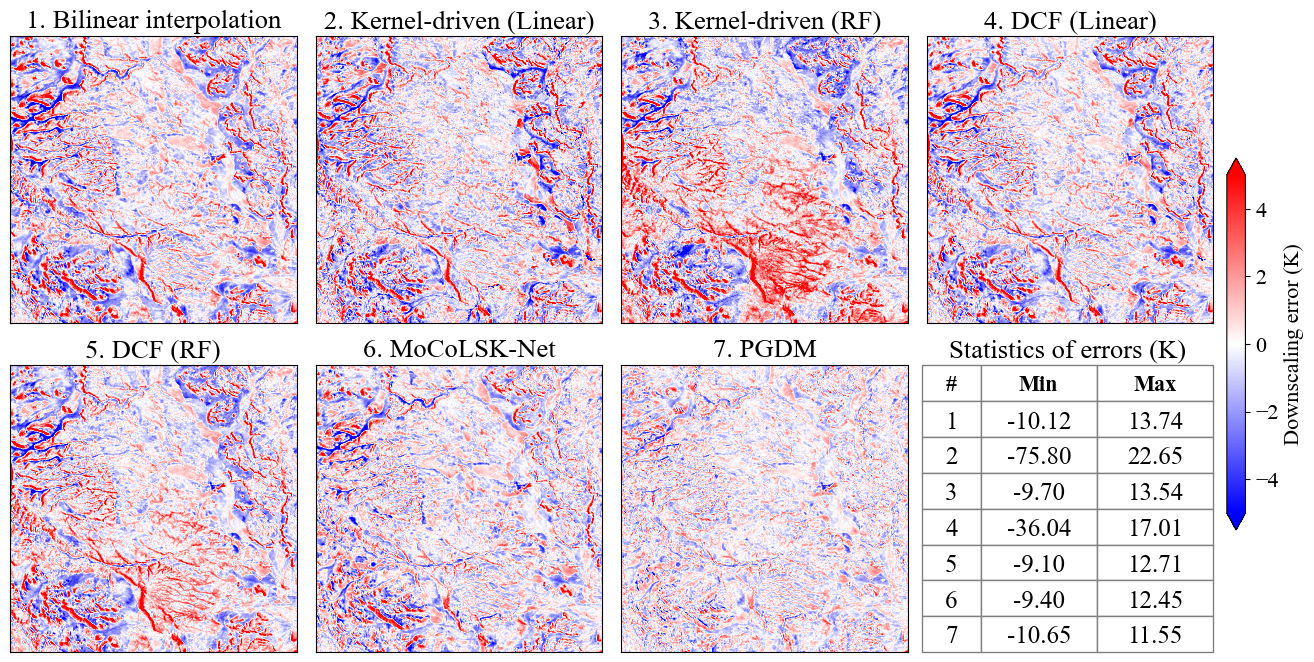

In [191]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
norm = mcolors.TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
axs = axs.flatten()
data = [['#', 'Min', 'Max']]

for i in range(7):
    lst_error = lst_all[i] - lst_all[-1]
    ax = axs[i]
    im = ax.imshow(lst_error, cmap='bwr', norm=norm)
    ax.set_title(f'{i+1}. {titles_all[i]}')
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    data.append([f"{i+1}", f"{lst_error.min():.2f}", f"{lst_error.max():.2f}"])

# add table for error metrics
ax = axs[7]
ax.axis('off')
ax.set_title('Statistics of errors (K)')
table = ax.table(cellText=data, cellLoc='center', colWidths=[0.2, 0.4, 0.4], bbox=[0.0, 0.0, 1, 1])
table.auto_set_font_size(False)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("gray")
    table_text = cell.get_text()
    table_text.set_horizontalalignment('center')
    table_text.set_verticalalignment('center_baseline')
    table_text.set_weight('bold') if row == 0 else None
    table_text.set_fontsize(18) if row >= 1  else table_text.set_fontsize(16)

# add colorbar
cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.015, pad=0.02, extend='both')
cbar.set_label('Downscaling error (K)')

fig.subplots_adjust(wspace=0.05, hspace=0.15, right=0.88)
plt.savefig(f'figs/dlst_error_{region}_{name}.tif', dpi=300, bbox_inches='tight')

In [179]:
for i in range(7):
    vmin = np.min([lst_all[i].min(), lst_all[-1].min()])
    vmax = np.max([lst_all[i].max(), lst_all[-1].max()])
    print(f"{titles_all[i]}: {vmin:.2f} - {vmax:.2f}")

Bilinear interpolation: 290.60 - 324.10
Kernel-driven (Linear): 277.96 - 370.88
Kernel-driven (RF): 290.60 - 324.10
DCF (Linear): 285.71 - 342.89
DCF (RF): 290.60 - 324.10
MoCoLSK-Net: 290.06 - 324.10
PGDM: 288.49 - 324.10


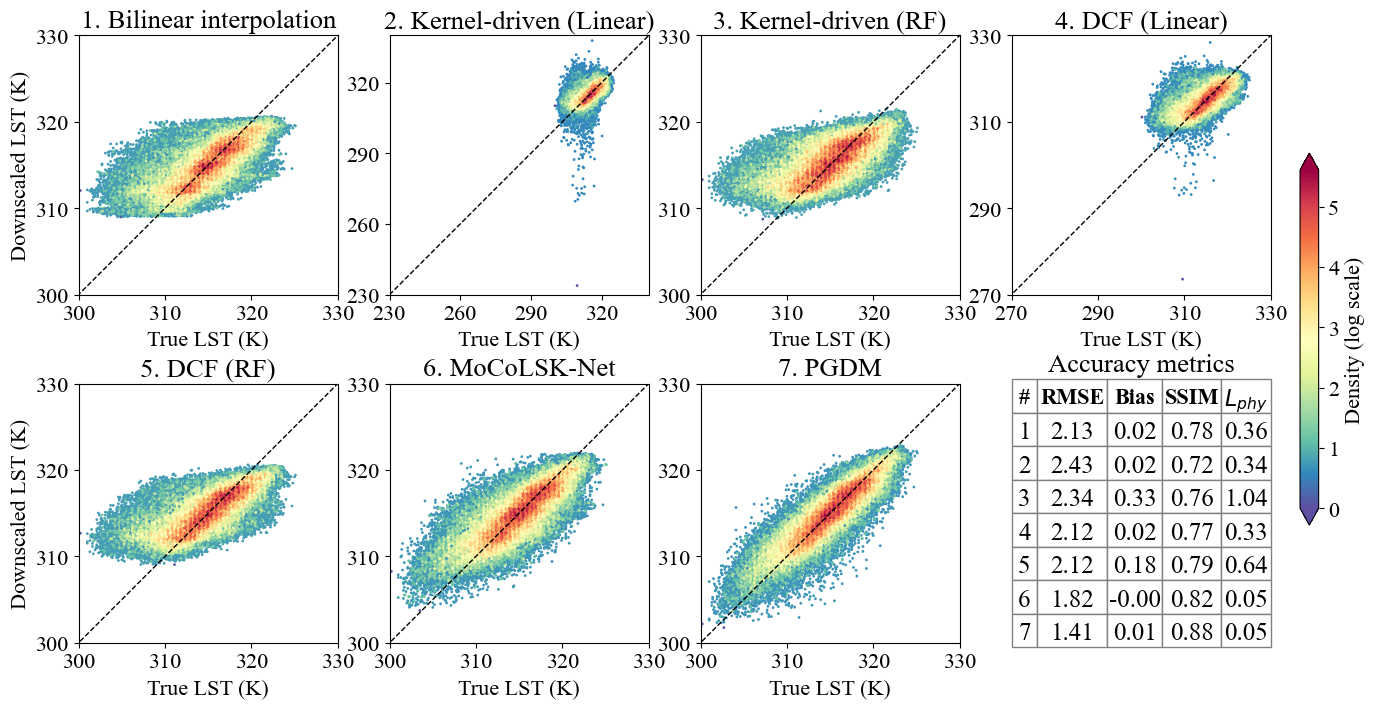

In [192]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
norm = mcolors.TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
data = [['#', 'RMSE', 'Bias', 'SSIM', '$L_{phy}$']]
axs = axs.flatten()
for i in range(7):
    ax = axs[i]
    # # for santiago
    # if i==1:
    #     v_minmax, gap = (260, 360), 20
    # elif i==3:
    #     v_minmax, gap = (260, 340), 20
    # else:
    #     v_minmax, gap = None, 10

    # # for lake tahoe
    # if i==1:
    #     v_minmax, gap = (280, 385), 35
    # elif i==3:
    #     v_minmax, gap = (285, 360), 25
    # else:
    #     v_minmax, gap = None, 10

    # for namibia
    if i==1:
        v_minmax, gap = (230, 340), 30
    elif i==3:
        v_minmax, gap = (270, 330), 20
    else:
        v_minmax, gap = None, 10

    # # for yueyang
    # if i==1:
    #     v_minmax, gap = (270, 375), 35
    # elif i==3:
    #     v_minmax, gap = (285, 345), 20
    # else:
    #     v_minmax, gap = (285, 325), 10

    scatter_obj = density_scatter(lst_all[-1].flatten(), lst_all[i].flatten(), ax, v_minmax=v_minmax, gap=gap,
                                  cmap='Spectral_r', s=1, n_bins=200)
    ax.set_title(f'{i+1}. {titles_all[i]}')
    ax.set_xlabel('True LST (K)')
    ax.set_aspect('equal', adjustable='box')
    
    # accuracy metrics
    rmse_val, bias_val, ssim_val, loss_phy = calculate_accuracy_metrics(
        lst_all[-1], lst_all[i], lr_size, factor, data_range=data_range)
    data.append([f"{i+1}", f"{rmse_val:.2f}", f"{bias_val:.2f}", f"{ssim_val:.2f}", f"{loss_phy:.2f}"])
    
    
axs[0].set_ylabel('Downscaled LST (K)')
axs[4].set_ylabel('Downscaled LST (K)')

# set ranges for given subplots
# for i in [0, 2, 4, 5, 6]:
#     axs[i].set_xlim(285, 340) # 335 for santiago and 340 for lake tahoe
#     axs[i].set_ylim(285, 340)

# add table for accuracy metrics
ax = axs[7]
ax.axis('off')
ax.set_title('Accuracy metrics')
table = ax.table(cellText=data, cellLoc='center', colWidths=[0.1, 0.27, 0.21, 0.23, 0.19], bbox=[0.0, 0.0, 1, 1])
table.auto_set_font_size(False)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("gray")
    table_text = cell.get_text()
    table_text.set_horizontalalignment('center')
    table_text.set_verticalalignment('center_baseline')
    table_text.set_weight('bold') if row == 0 else None
    table_text.set_fontsize(18) if row >= 1  else table_text.set_fontsize(16)

# add colorbar
cbar = fig.colorbar(scatter_obj, ax=axs, orientation='vertical', fraction=0.015, pad=0.02, extend='both')
cbar.set_label('Density (log scale)')

fig.subplots_adjust(wspace=0.2, hspace=0.3, right=0.87)

In [193]:
fig.savefig(f'figs/dlst_scatter_{region}_{name}.tif', dpi=300, bbox_inches='tight')